In [ ]:
# Documentation of basic commands and uses

## Message Suppression
### stdout suppression 
# |> sink(tempfile() (top of the file)
# |> sink() (at bottom of file to close)

### stderr suppression
# |> msg_sink <- file(tempfile(), open = "wt") // sing(msg_sink, type = "message") - top of the file
# |> sink(type = "message") // close(msg_sink) - at the end of the file to close

### Package Loading Suppression
# |> suppressPackageStartupMessages(library(XYZ))

In [2]:
# Package Loading
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(rvg))
suppressPackageStartupMessages(library(broom))
suppressPackageStartupMessages(library(officer))
suppressPackageStartupMessages(library(flextable))
suppressPackageStartupMessages(library(sensitivity))
suppressPackageStartupMessages(library(lm.beta))
suppressPackageStartupMessages(library(igraph))
suppressPackageStartupMessages(library(ggraph))
suppressPackageStartupMessages(library(janitor))
suppressPackageStartupMessages(library(tidygraph))
suppressPackageStartupMessages(library(patchwork))
suppressPackageStartupMessages(library(knitr))

In [19]:
# Sourcing Helpers and Files
source("./functions.R")
source("./data_processing.R")
source("./plots.R")

In [ ]:
# LHS and GA sourcing
# Sink declaration and quiet tidyverse terminal alerts globally
options(readr.show_col_types = FALSE)
options(tidyverse.quiet = TRUE)
sink(tempfile())

# Second sink for stderr
msg_sink <- file(tempfile(), open = "wt")
sink(msg_sink, type = "message")

# source framework_file
source("framework_analysis.R")

# empirical data loading 4/6/26
df_empirical <- empirical_prep("./data/data_complete_anonymised.csv")

# Closed Sink
sink(type = "message")
close(msg_sink)
sink()

# LHS pipeline
if (!exists("processed_lhs")) {
  processed_lhs <- process_run(run_configs$lhs_main)
}

if(exists("processed_lhs")) {
  lhs_bundle <- list(
    sim_inputs = processed_lhs,
    df_empirical = df_empirical
  )
  lhs_outputs <- analyze_processed_run(lhs_bundle)
}

# GA pipeline
if (!exists("processed_ga")) {
  processed_ga <- process_run(run_configs$ga_main)
}

if(exists("processed_ga")) {
  ga_bundle <- list( # 4/6/26
    sim_inputs = processed_ga,
    df_empirical = df_empirical
  )
  ga_outputs <- analyze_processed_run(ga_bundle)
}

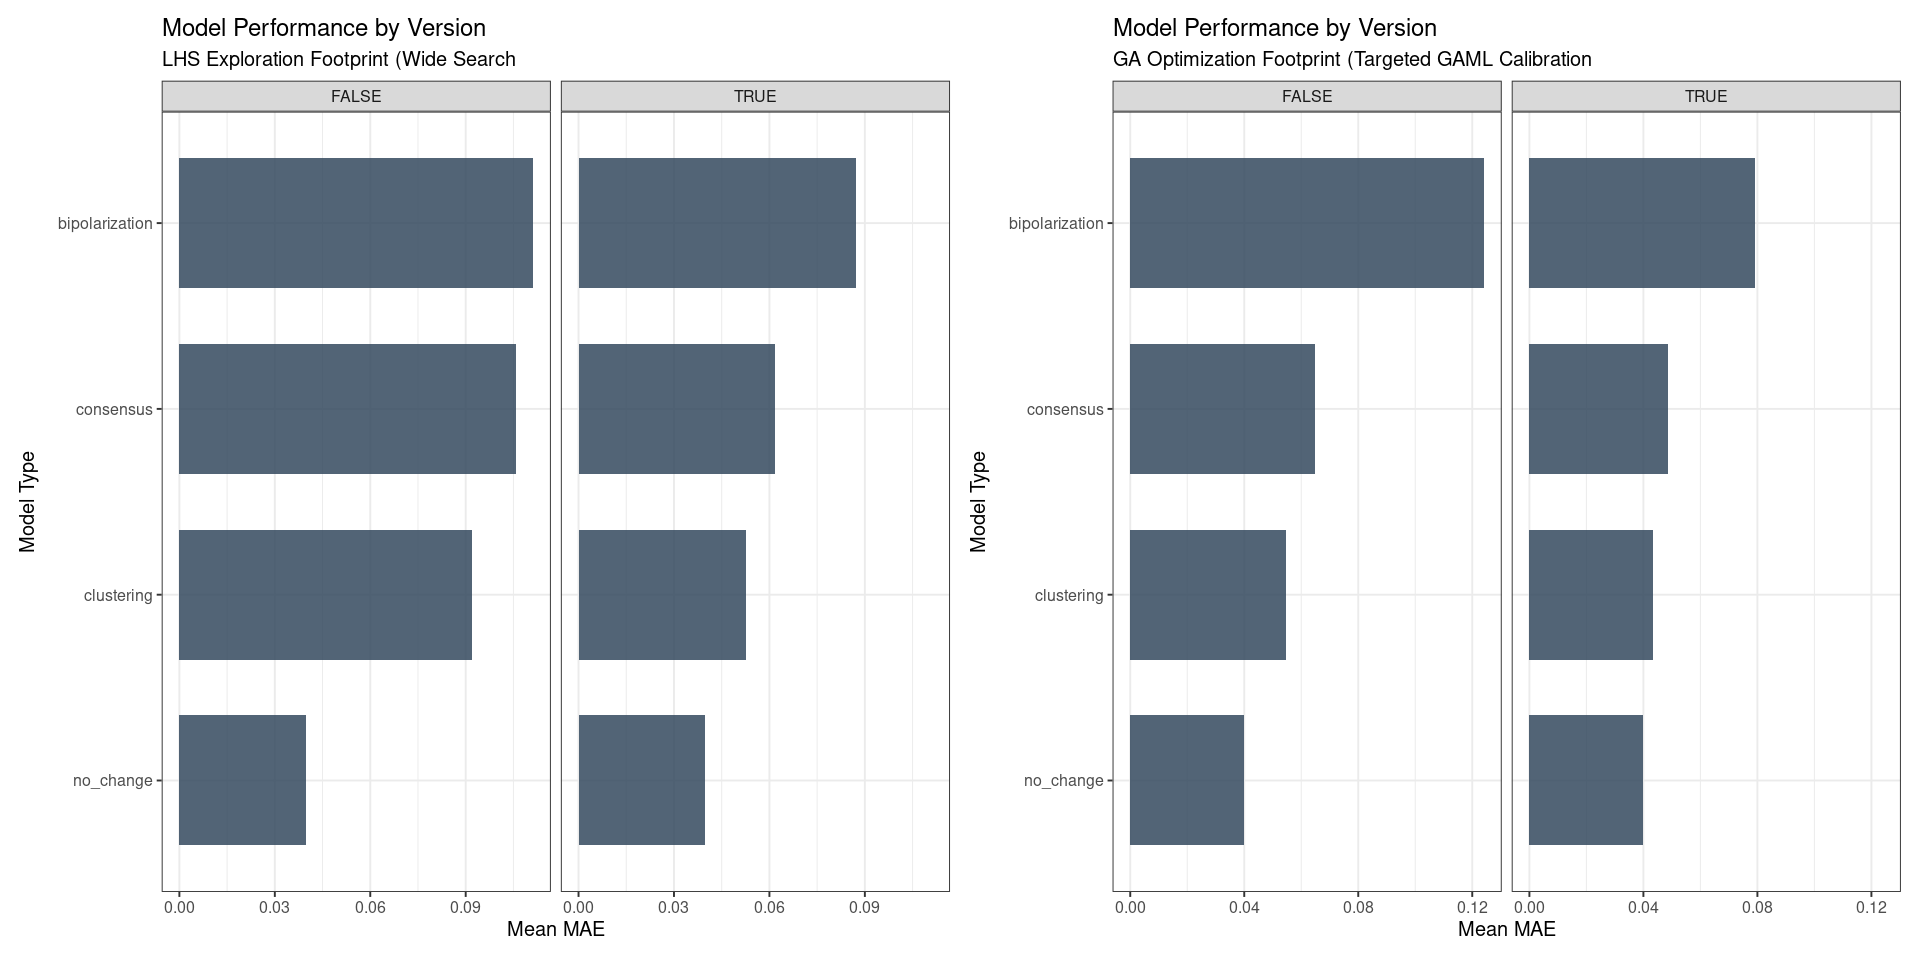

In [20]:
# sandbox optimization footprints
options(repr.plot.width = 16, repr.plot.height = 8)

if (exists("ga_outputs") && !is.null(ga_outputs$results$comparisons$ranking)) {
  p_lhs <- lhs_outputs$plots$model_performance_rank_main() +
    labs(subtitle = "LHS Exploration Footprint (Wide Search")
  
  p_ga <- ga_outputs$plots$model_performance_rank_main() +
    labs(subtitle = "GA Optimization Footprint (Targeted GAML Calibration")
  
  p_lhs + p_ga + plot_layout(guides = "collect")
} else {
  cat("\n\n ** system note: Active GA Package not detected for this specific run",
      "GAML bounds successfully written to disk. run GA engine to append optimization data")
}

In [24]:
# seed audit (do lhs and ga use the same seeds? if so, use a paired t test to determine relative improvement)

# cat message
cat("=== RUN CONFIG SEED AUDIT ===\n")

lhs_batch_df <- lhs_outputs$inputs$raw
ga_batch_df <- ga_outputs$inputs$raw

# helper function to identify columns with seed
find_seed_col <- function(df) {
  cols <- colnames(df)
  match <- cols[grepl("seed", cols, ignore.case = TRUE)]
  return(match)
}

lhs_seed_col <- find_seed_col(lhs_batch_df)
ga_seed_col <- find_seed_col(ga_batch_df)

if (length(lhs_seed_col) > 0) {
  lhs_seeds <- unique(lhs_batch_df[[lhs_seed_col]])
  cat("LHS seeds found:", paste(lhs_seeds, collapse = ", "), "\n")
} else {
  cat("Could not find LHS seed column")
  print(head(colnames(lhs_batch_df), 10))
}

if (length(ga_seed_col) > 0) {
  ga_seeds <- unique(ga_batch_df[[ga_seed_col]])
  cat("GA seeds found:", paste(ga_seeds, collapse = ", "), "\n")
} else {
  cat("Could not find GA seed column")
  print(head(colnames(ga_batch_df), 10))
}

# check for structural alignment
if (length(lhs_seed_col) > 0 && length(ga_seed_col) > 0) {
  cat("\n--- Conclusion ---\n")
  if (length(lhs_seeds) == length(ga_seeds) && all(lhs_seeds == ga_seeds)) {
    cat("Seeds match perfectly: proceed with paired t test. \n")
  } else {
    cat("Seeds do not match: proceed with independent t test. \n")
  }
}

=== RUN CONFIG SEED AUDIT ===
LHS seeds found: 8636175130330607616, 7139002048363152384, 7240713591891685376, 4692690466958798848, 6905470370856337408 
GA seeds found: 6905470370856337408, 7139002048363152384, 7240713591891685376, 4692690466958798848, 8636175130330607616, 4477927936947039232, 4286360386944651264, 7128893484183252992, 5702577027890589696, 4342572612484808704, 7043372089166577664, 8803618445054126080, 4398895106259038208, 109591146466576384, 1841142524168585216 

--- Conclusion ---
Seeds do not match: proceed with independent t test. 


In [32]:
# GA-LHS ranking test (t test)
# extract mae values
lhs_vector <- lhs_outputs$inputs$raw$mae
ga_vector <- ga_outputs$inputs$raw$mae

# run welch's t test
defensive_ttest <- t.test(ga_vector, lhs_vector, paired = FALSE, alternative = "two.sided")

# print results
print(defensive_ttest)


	Welch Two Sample t-test

data:  ga_vector and lhs_vector
t = -48.962, df = 63394, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.02405216 -0.02220060
sample estimates:
 mean of x  mean of y 
0.06439969 0.08752607 

